# Step 12 — Sentiment ablation comparison

We remove sentiment components one at a time to identify whether headline tone, coverage volume, or their combination drove the earlier result. All models use the same chronological split and November 22, 2024 cutoff.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_momentum_sentiment.csv"
CUTOFF_DATE = pd.Timestamp("2024-11-22")
data = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date").sort_index()
data = data.loc[data.index <= CUTOFF_DATE].copy()

In [2]:
test_size = int(len(data) * 0.25)
test_start = len(data) - test_size
train = data.iloc[: test_start - 5].copy()
test = data.iloc[test_start:].copy()
y_train = train["outperformed"].astype(int)
y_test = test["outperformed"].astype(int)
print(f"Training: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Testing: {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

Training: 2023-01-10 to 2024-05-30 (349 rows)
Testing: 2024-06-07 to 2024-11-22 (118 rows)


## Fit the ablation models

Each logistic regression uses standardized inputs learned from training data only.

In [3]:
feature_sets = {
    "Tone only": ["average_sentiment_5d"],
    "Headline count only": ["headline_count_5d"],
    "Tone + count": ["average_sentiment_5d", "headline_count_5d"],
}

results = {
    "Majority baseline": {
        "Accuracy": accuracy_score(y_test, [int(y_train.mode().iloc[0])] * len(y_test)),
        "Precision": precision_score(y_test, [int(y_train.mode().iloc[0])] * len(y_test)),
        "Recall": recall_score(y_test, [int(y_train.mode().iloc[0])] * len(y_test)),
        "ROC AUC": 0.5,
    }
}
coefficients = []

for name, features in feature_sets.items():
    model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
    model.fit(train[features], y_train)
    predicted = model.predict(test[features])
    probability = model.predict_proba(test[features])[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision": precision_score(y_test, predicted, zero_division=0),
        "Recall": recall_score(y_test, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probability),
    }
    for feature, coefficient in zip(features, model.named_steps["logisticregression"].coef_[0]):
        coefficients.append({
            "Model": name, "Feature": feature, "Standardized coefficient": coefficient
        })

results = pd.DataFrame(results).T
results.round(3)

,Accuracy,Precision,Recall,ROC AUC
Majority baseline,0.500,0.500,1.000,0.500
Tone only,0.627,0.600,0.763,0.672
Headline count only,0.441,0.463,0.746,0.472
Tone + count,0.636,0.643,0.610,0.618


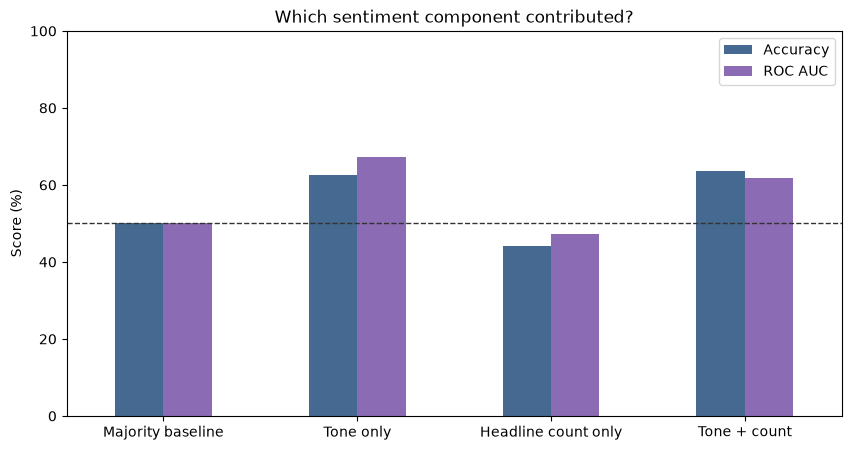

In [4]:
ax = (results[["Accuracy", "ROC AUC"]] * 100).plot.bar(
    figsize=(10, 5), rot=0, color=["#456990", "#8b6bb3"]
)
ax.axhline(50, color="#333333", linestyle="--", linewidth=1)
ax.set_ylim(0, 100)
ax.set_ylabel("Score (%)")
ax.set_title("Which sentiment component contributed?")
ax.set_xlabel("")
plt.show()

In [5]:
pd.DataFrame(coefficients).round(3)

,Model,Feature,Standardized coefficient
0,Tone only,average_sentiment_5d,-0.088
1,Headline count only,headline_count_5d,0.105
2,Tone + count,average_sentiment_5d,-0.076
3,Tone + count,headline_count_5d,0.095


## Interpretation limit

Ablation identifies which variables carry predictive information in this fixed split. It does not establish causation or guarantee that the relationship persists in other time periods or stocks.